# Import Libraries

In [1]:
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Evaluation
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Explainability
import shap

import warnings
warnings.filterwarnings("ignore")

# Load Dataset

In [2]:
df = pd.read_csv("student_performance_updated_1000.csv")

df.head()

,StudentID,Name,Gender,AttendanceRate,StudyHoursPerWeek,PreviousGrade,ExtracurricularActivities,ParentalSupport,FinalGrade,Study Hours,Attendance (%),Online Classes Taken
0,1.0,John,Male,85.0,15.0,78.0,1.0,High,80.0,4.8,59.0,False
1,2.0,Sarah,Female,90.0,20.0,85.0,2.0,Medium,87.0,2.2,70.0,True
2,3.0,Alex,Male,78.0,10.0,65.0,0.0,Low,68.0,4.6,92.0,False
3,4.0,Michael,Male,92.0,25.0,90.0,3.0,High,92.0,2.9,96.0,False
4,5.0,Emma,Female,NaN,18.0,82.0,2.0,Medium,85.0,4.1,97.0,True


# Data Cleaning

### Drop useless columns

In [3]:
df = df.drop(columns=["StudentID", "Name"])

### Fix duplicate columns

In [4]:
# Keep consistent columns
df = df.drop(columns=["Study Hours", "Attendance (%)"])

df.rename(columns={
    "StudyHoursPerWeek": "StudyHours",
    "AttendanceRate": "Attendance"
}, inplace=True)

### Check missing values

In [5]:
df.isnull().sum()

,0
Gender,48
Attendance,40
StudyHours,50
PreviousGrade,33
ExtracurricularActivities,43
ParentalSupport,22
FinalGrade,40
Online Classes Taken,25


In [6]:
df = df.dropna()

In [7]:
df.isnull().sum()

,0
Gender,0
Attendance,0
StudyHours,0
PreviousGrade,0
ExtracurricularActivities,0
ParentalSupport,0
FinalGrade,0
Online Classes Taken,0


# EDA (Exploratory Data Analysis)

### Basic Overview

In [8]:
# Dataset shape
print(df.shape)

# Data types
print(df.dtypes)

# Summary statistics
df.describe()

(743, 8)
Gender                        object
Attendance                   float64
StudyHours                   float64
PreviousGrade                float64
ExtracurricularActivities    float64
ParentalSupport               object
FinalGrade                   float64
Online Classes Taken          object
dtype: object


,Attendance,StudyHours,PreviousGrade,ExtracurricularActivities,FinalGrade
count,743.000000,743.000000,743.000000,743.000000,743.000000
mean,85.427995,17.706595,77.662180,1.526245,80.025572
std,7.304127,6.374228,10.116851,1.036554,9.493118
min,70.000000,8.000000,60.000000,0.000000,62.000000
25%,82.000000,12.000000,70.000000,1.000000,72.000000
50%,85.000000,18.000000,78.000000,2.000000,80.000000
75%,91.000000,22.000000,86.000000,2.000000,88.000000
max,95.000000,30.000000,90.000000,3.000000,92.000000


# Encode Categorical Variables

In [9]:
le = LabelEncoder()

categorical_cols = [
    "Gender",
    "ExtracurricularActivities",
    "ParentalSupport"
]

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

# Convert Target Variable

In [10]:
def grade_category(grade):
    if grade >= 75:
        return "High"
    elif grade >= 50:
        return "Medium"
    else:
        return "Low"

df["Performance"] = df["FinalGrade"].apply(grade_category)

df.drop("FinalGrade", axis=1, inplace=True)

### Encode target

In [11]:
df["Performance"] = le.fit_transform(df["Performance"])

# Feature & Target Split

In [12]:
X = df.drop("Performance", axis=1)
y = df["Performance"]

# Train-Test Split

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Feature Scaling

In [14]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Train Models

## Logistic Regression

In [15]:
lr = LogisticRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

## Decision Tree

In [16]:
dt = DecisionTreeClassifier(max_depth=5)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

## Random Forest

In [17]:
rf = RandomForestClassifier(n_estimators=100)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

# Evaluation

## Accuracy

In [18]:
print("Logistic Regression:", accuracy_score(y_test, y_pred_lr))
print("Decision Tree:", accuracy_score(y_test, y_pred_dt))
print("Random Forest:", accuracy_score(y_test, y_pred_rf))

Logistic Regression: 0.697986577181208
Decision Tree: 0.6845637583892618
Random Forest: 0.6375838926174496


## Confusion Matrix

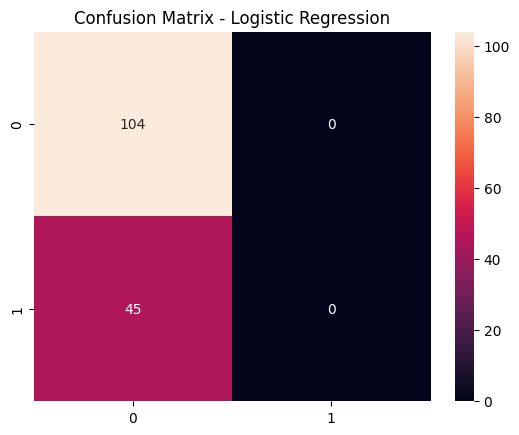

In [19]:
sns.heatmap(confusion_matrix(y_test, y_pred_lr), annot=True, fmt='d')
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

## Classification Report

In [20]:
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.70      1.00      0.82       104
           1       0.00      0.00      0.00        45

    accuracy                           0.70       149
   macro avg       0.35      0.50      0.41       149
weighted avg       0.49      0.70      0.57       149



# Model Selection

In [21]:
final_model = lr

# Explainable AI (SHAP)

In [22]:
explainer = shap.Explainer(final_model, X_train)
shap_values = explainer(X_test)

## SHAP Summary Plot

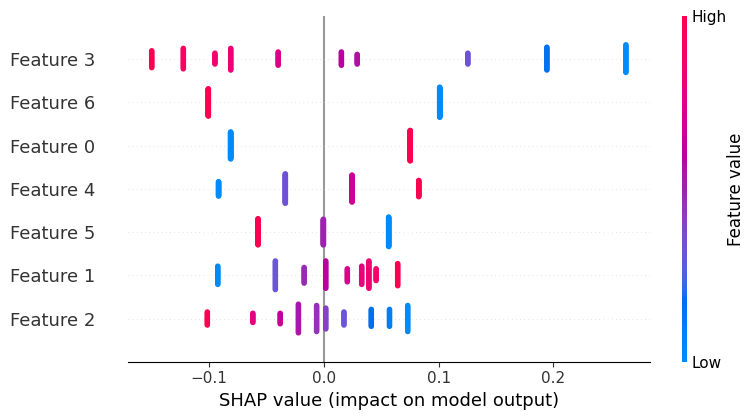

In [23]:
shap.summary_plot(shap_values, X_test)

# Save Model

In [24]:
import joblib

joblib.dump(final_model, "student_model.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

# Visualization

### Distribution of Target Variable

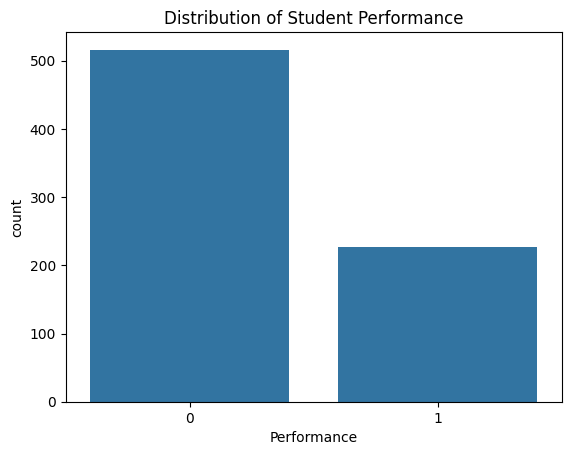

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Performance', data=df)
plt.title("Distribution of Student Performance")
plt.show()

### Performance Distribution

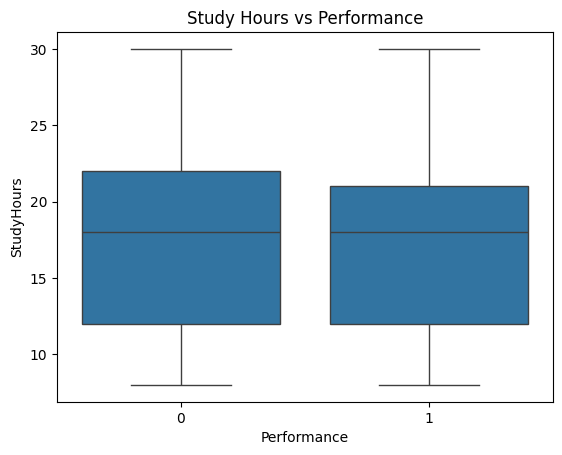

In [26]:
sns.boxplot(x='Performance', y='StudyHours', data=df)
plt.title("Study Hours vs Performance")
plt.show()

### Study Behavior Impact

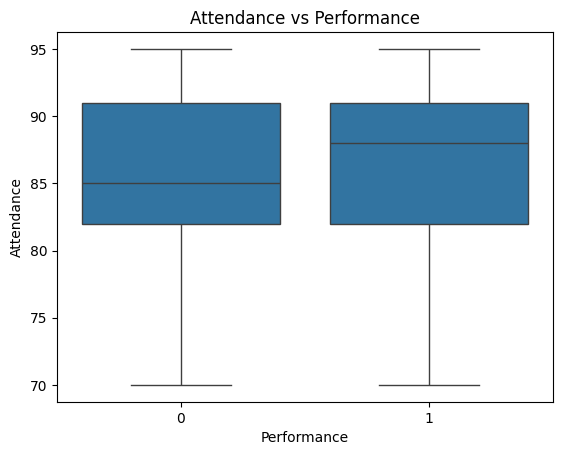

In [27]:
sns.boxplot(x='Performance', y='Attendance', data=df)
plt.title("Attendance vs Performance")
plt.show()

## Correlation Heatmap

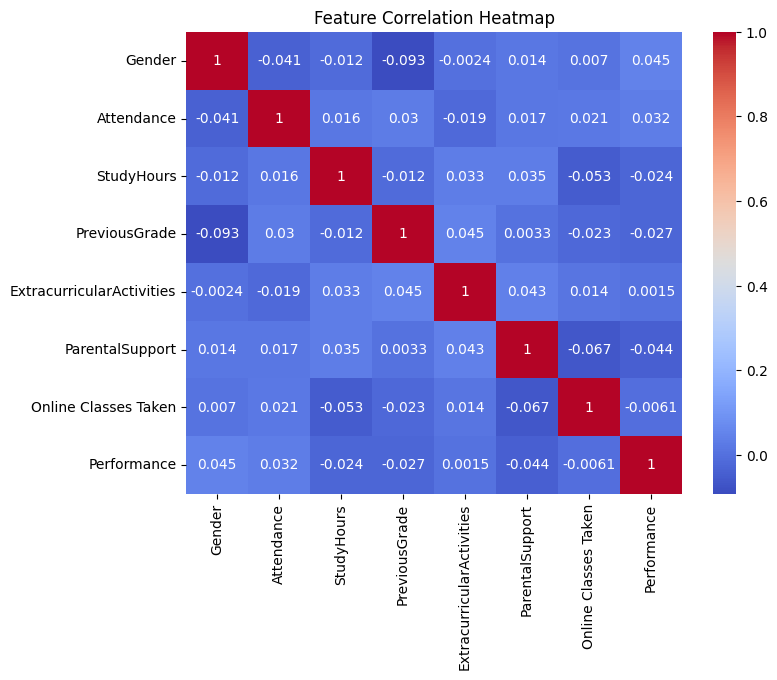

In [28]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()